# MalthusJAX Fitness Module — Technical Overview & Guide

This notebook provides an **executable, interactive guide** to the `malthusjax.core.fitness` package.

**Target audience**: Developers implementing custom evaluators, adapting external benchmarks, or integrating domain-specific data into fitness pipelines.

**What you'll learn**:
- The **Abstract Evaluator** paradigm and type-safe configuration
- How to handle optimization direction (maximize vs. minimize) JAX-safely
- **Static configuration** and data storage patterns
- Built-in evaluators: Analytical (Sphere, Griewank), Combinatorial (Knapsack), BBOB, TSP
- **Data management** for large problem datasets
- **Implementation best practices** for custom evaluators
- Working examples: creating and evaluating populations

---

In [1]:
from typing import Tuple

import jax
import jax.lax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Import MalthusJAX evaluator and genome modules
from malthusjax.core.fitness.base import BaseEvaluator, BaseEvaluatorConfig
from malthusjax.core.genome.binary_genome import BinaryGenome, BinaryGenomeConfig, BinaryPopulation
from malthusjax.core.genome.real_genome import RealGenome, RealGenomeConfig, RealPopulation

print(f"JAX version: {jax.__version__}")

JAX version: 0.10.0


## 1. The Abstract Evaluator Paradigm

### Core Architecture

MalthusJAX evaluators follow a **separation of concerns** pattern:

- **`BaseEvaluator[G, C, D]`** is a generic abstract class:
  - `G`: A `BaseGenome` subtype (RealGenome, BinaryGenome, CategoricalGenome, etc.)
  - `C`: A `BaseEvaluatorConfig` subtype (problem-specific configuration)
  - `D`: An arbitrary data payload (training data, distance matrices, game boards, etc.)

### Functional Split

**Single genome evaluation** (you implement this):
```python
def evaluate(self, genome: G) -> chex.Numeric
    # Implement the per-individual math here
    # Receives a single (non-batched) genome instance
    # Return a scalar fitness value
```

**Population evaluation** (provided by `BaseEvaluator`):
```python
def evaluate_population(self, population: BasePopulation[G]) -> BasePopulation[G]
    # Uses `jax.vmap(self.evaluate)` to vectorize across population
    # Returns population with updated fitness values
```

### Why This Design

1. **Developer simplicity**: Write scalar logic once, get batched evaluation automatically
2. **Performance**: JAX's `vmap` provides O(N) batched evaluation on GPU/TPU
3. **Testability**: Single-individual functions are easier to test and debug
4. **JAX compatibility**: Pure functions enable `jit`, `vmap`, `grad`, etc.

## 2. Type-Safe Configuration

### The BaseEvaluatorConfig Pattern

All evaluators use a `BaseEvaluatorConfig` dataclass. Key points:

| Field | Type | Purpose |
|-------|------|----------|
| `maximize` | `bool` | **Mandatory**. If True, higher fitness is better. Engines use this to sort/rank candidates. |
| `seed` | int (optional) | For stochastic problems or initialization |
| `fn_name` | str (optional) | For BBOB/benchmark selection |
| Custom fields | type-dependent | Problem-specific parameters (weights, capacities, etc.) |

### Static Annotation

Mark non-trainable fields with `pytree_node=False` to prevent JAX from treating them as mutable state:

```python
@struct.dataclass
class MyConfig(BaseEvaluatorConfig):
    maximize: bool  # Always required
    param1: int = struct.field(pytree_node=False)  # Static config
    param2: str = struct.field(pytree_node=False)  # Static config
```

This ensures:
- Config changes don't trigger JIT recompilation
- Memory efficiency: config isn't replicated during `vmap`

## 3. Handling Optimization Direction: JAX-Safe Patterns

### The Problem

MalthusJAX engines **always maximize**. So if a problem requires **minimization**, the evaluator must negate the objective.

### ❌ Anti-Pattern: Python Control Flow

```python
# WRONG: This creates separate XLA graphs and can cause recompilation!
if self.config.maximize:
    return val
else:
    return -val
```

### ✅ Correct Pattern: jax.lax.select

Use `jax.lax.select` to keep control flow inside the JIT-compiled XLA graph:

```python
# RIGHT: This composes cleanly into a single XLA graph
val = compute_objective(...)
return jax.lax.select(self.config.maximize, val, -val)
```

**Why**: `jax.lax.select` is a **data-dependent** operation that JAX traces directly, unlike Python `if/else` which creates branching at trace time.

In [2]:
# Demonstrate jax.lax.select for optimization direction

# Sphere function: f(x) = sum(x^2), minimization problem
x = jnp.array([1.0, 2.0, 3.0])
sphere_value = jnp.sum(x**2)

print(f"Raw sphere value (to minimize): {sphere_value}")

# Maximization: negate the value
maximize = True
fitness_maximize = jax.lax.select(maximize, sphere_value, -sphere_value)
print(f"Fitness (maximize=True): {fitness_maximize}")

# Minimization: return negated value (so lower objectives become higher fitness)
minimize = False
fitness_minimize = jax.lax.select(minimize, sphere_value, -sphere_value)
print(f"Fitness (maximize=False): {fitness_minimize}")

print("\n✓ Both strategies compose into a single XLA graph with jax.lax.select")

Raw sphere value (to minimize): 14.0
Fitness (maximize=True): 14.0
Fitness (maximize=False): -14.0

✓ Both strategies compose into a single XLA graph with jax.lax.select


## 4. Specialized Evaluator Implementations

### 4.1 Analytical Evaluators

**Purpose**: Classic continuous test functions (Sphere, Griewank, Rastrigin, etc.)

**Genomes**: `RealGenome` with arbitrary shape

**Pattern**:
```python
class SphereEvaluator(BaseEvaluator[RealGenome, AnalyticalConfig, None]):
    def evaluate(self, genome: RealGenome) -> chex.Numeric:
        objective = jnp.sum(genome.values ** 2)
        return jax.lax.select(self.config.maximize, objective, -objective)
```

### 4.2 Combinatorial Evaluators

**Purpose**: Discrete optimization (Knapsack, TSP, SAT, etc.)

**Genomes**: `BinaryGenome`, `CategoricalGenome`, or encoded `RealGenome`

**Data handling**: Static problem data (weights, values, capacity) stored as `pytree_node=False`

**Example—Knapsack**:
- Data: items with weights and values, capacity constraint
- Genome: binary string (1 = include item, 0 = exclude)
- Fitness: total value, with penalty for constraint violation

### 4.3 BBOB (Black Box Optimization Benchmark) Adapter

**Purpose**: Standardized benchmark functions (100+ test problems)

**Integration**: Wraps evosax `BBOBProblem` under the hood

**Key details**:
- Handles sign convention: MalthusJAX maximizes, BBOB usually minimizes
- For `maximize=False`, evaluator **negates** the raw evosax score
- Problem state stored as `pytree_node=False` to avoid recompilation

### 4.4 TSP (Traveling Salesman Problem)

**Purpose**: Find shortest tour visiting all cities exactly once

**Encoding**: "Random Key" encoding
- Genome: `RealGenome` with values in (0, 1)
- Tour: `argsort(genome.values)` produces permutation
- Why: Continuous values allow gradient-based operators; argsort differentiably converts to permutation

**Data**: Distance matrix (symmetric or asymmetric)
- Computation: `total_distance = distance_matrix[tour, roll(tour)]` (circular sum)
- For minimization: return distance; for maximization: return -distance

In [3]:
# Example 1: Analytical Evaluator (Sphere Function)
# Minimize: f(x) = sum(x^2) — optimum at x = [0, 0, ..., 0]

from flax import struct


@struct.dataclass
class SphereConfig(BaseEvaluatorConfig):
    maximize: bool = False  # Minimization problem


@struct.dataclass
class SphereEvaluator(BaseEvaluator):
    """Simple sphere function evaluator."""

    config: SphereConfig
    data: None = None

    def evaluate(self, genome: RealGenome) -> jnp.ndarray:
        """Compute sphere fitness for a single genome."""
        objective = jnp.sum(genome.values**2)
        # Scale objective: for minimize=False, negate it
        return jax.lax.select(self.config.maximize, objective, -objective)


# Create evaluator and population
config = SphereConfig(maximize=False)
evaluator = SphereEvaluator(config=config, data=None)

# Create population in 5-D space
genome_config = RealGenomeConfig(shape=(5,), bounds=(-5.0, 5.0), dtype=jnp.float32)
key = jax.random.PRNGKey(0)
pop = RealPopulation.init_random(key, genome_config, size=16)

print("=== Sphere Evaluator ===")
print("Problem: Minimize sum(x^2)")
print(f"Maximize config: {config.maximize}")
print(f"Population size: {len(pop)}")

# Evaluate population (this uses vmap internally)
pop_evaluated = evaluator.evaluate_population(pop)

min_fit = jnp.min(pop_evaluated.fitness)
max_fit = jnp.max(pop_evaluated.fitness)
print(f"Fitness range: [{min_fit:.4f}, {max_fit:.4f}]")
print(f"Best gene index: {jnp.argmax(pop_evaluated.fitness)}")
print(f"Best fitness: {jnp.max(pop_evaluated.fitness):.4f}")

=== Sphere Evaluator ===
Problem: Minimize sum(x^2)
Maximize config: False
Population size: 16
Fitness range: [-71.3548, -6.6719]
Best gene index: 15
Best fitness: -6.6719


## 5. Data Management

### Static Data Storage

Large or immutable problem data should be stored in the evaluator's `data` field, marked with `pytree_node=False`:

```python
@struct.dataclass
class MyEvaluator(BaseEvaluator[G, C, D]):
    config: C
    data: D = struct.field(pytree_node=False)  # Mark as static
```

### Benefits

1. **Memory efficiency**: Data isn't replicated per vmap instance
2. **JIT stability**: Static data doesn't trigger recompilation
3. **Clarity**: Decouples mutable state (genomes, fitness) from static parameters

### Common Data Patterns

- **RegressionData**: `Tuple[chex.Array, chex.Array]` = `(X, y)` for supervised learning
- **Distance matrices**: For TSP, graph problems
- **Lookup tables**: For discrete domains
- **Problem instances**: evosax state, BBOB problem descriptors

## 6. Implementation Best Practices Checklist

When implementing a new `BaseEvaluator` subclass, follow this checklist:

### Type Safety
- ✅ Use `chex.Numeric` as return type for `evaluate`
- ✅ Use `cast(Type, cast(Any, obj).replace(...))` for type-safe population updates

### JAX Compatibility
- ✅ Make `evaluate` pure: no side effects, no global state mutations
- ✅ Use `jax.lax.select` for control flow depending on `config.maximize`
- ✅ Avoid Python `if/else` on tracer values inside JIT
- ✅ If dispatching among small functions, use `jax.lax.switch` instead of `if/else`

### Numerical Stability
- ✅ Protected division: `jnp.where(jnp.abs(y) < eps, 0.0, x / y)`
- ✅ Log-domain math: `jnp.where(x > 0, jnp.log(x), fallback_value)`
- ✅ NaN/inf handling: `jnp.nan_to_num(result, nan=fallback, posinf=max_val, neginf=min_val)`

### Configuration
- ✅ Make `maximize` explicit in every evaluator config
- ✅ Mark static config with `pytree_node=False` to avoid JIT bloat
- ✅ For third-party adapters, provide a `.create()` factory method

### Testing
- ✅ Test single-genome evaluation independently
- ✅ Compare `evaluate_population(pop)` with manually vmapped results
- ✅ Verify `maximize=True` and `maximize=False` produce opposite rankings

In [4]:
# Example 2: Comparing maximize vs. minimize for the same problem

from flax import struct


@struct.dataclass
class GriewankConfig(BaseEvaluatorConfig):
    maximize: bool = False


@struct.dataclass
class GriewankEvaluator(BaseEvaluator):
    """Griewank function: complex multimodal landscape."""

    config: GriewankConfig
    data: None = None

    def evaluate(self, genome: RealGenome) -> jnp.ndarray:
        x = genome.values
        n = jnp.shape(x)[0]

        # Griewank function
        sum_term = jnp.sum(x**2) / 4000.0
        prod_term = jnp.prod(jnp.cos(x / jnp.sqrt(jnp.arange(1, n + 1, dtype=x.dtype))))
        objective = 1.0 + sum_term - prod_term

        # Apply optimization direction
        return jax.lax.select(self.config.maximize, -objective, objective)


# Test with maximize=False (minimization)
config_min = GriewankConfig(maximize=False)
evaluator_min = GriewankEvaluator(config=config_min, data=None)

genome_config = RealGenomeConfig(shape=(3,), bounds=(-10.0, 10.0), dtype=jnp.float32)
key = jax.random.PRNGKey(42)
pop = RealPopulation.init_random(key, genome_config, size=8)

pop_min = evaluator_min.evaluate_population(pop)
best_idx_min = jnp.argmax(pop_min.fitness)
worst_idx_min = jnp.argmin(pop_min.fitness)

print("=== Griewank: Minimization (maximize=False) ===")
print(f"Best fitness (highest in min mode): {pop_min.fitness[best_idx_min]:.4f}")
print(f"Worst fitness (lowest in min mode): {pop_min.fitness[worst_idx_min]:.4f}")
print(f"Best genome: {pop_min.genes.values[best_idx_min]}")

# Test with maximize=True (maximization of negated objective)
config_max = GriewankConfig(maximize=True)
evaluator_max = GriewankEvaluator(config=config_max, data=None)

pop_max = evaluator_max.evaluate_population(pop)
best_idx_max = jnp.argmax(pop_max.fitness)

print("\n=== Griewank: Maximization (maximize=True) ===")
print(f"Best fitness (in max mode): {pop_max.fitness[best_idx_max]:.4f}")
print(f"Best genome: {pop_max.genes.values[best_idx_max]}")

# Verify: in min mode, lower objective is higher fitness (negated)
# In max mode, higher objective is higher fitness (negated again)
print("\n✓ Optimization direction handled correctly via jax.lax.select")

=== Griewank: Minimization (maximize=False) ===
Best fitness (highest in min mode): 1.4938
Worst fitness (lowest in min mode): 0.9153
Best genome: [ 2.271428  -0.076859   1.2135673]

=== Griewank: Maximization (maximize=True) ===
Best fitness (in max mode): -0.9153
Best genome: [-1.714809 -9.531665 -4.585371]

✓ Optimization direction handled correctly via jax.lax.select


## 7. Quick Examples: Common Workflows

### Pattern 1: Evaluate a Population

Once you have an evaluator and a population, evaluation is one line:

```python
new_pop = evaluator.evaluate_population(population)
# new_pop.fitness now contains batched fitness values
# All genomes that had NaN fitness are now evaluated
```

### Pattern 2: Lazy Evaluation (Pending Fitness)

Use `spawn_offspring` to create a population with NaN fitness (pending evaluation):

```python
# Create offspring with pending fitness
new_genes = ...  # some mutated/recombined genes
offspring = parent_pop.spawn_offspring(new_genes)  # fitness = NaN

# Later, evaluate when ready
offspring = evaluator.evaluate_population(offspring)
```

### Pattern 3: Custom Evaluation with Penalty

For problems with constraints:

```python
def evaluate(self, genome: G) -> chex.Numeric:
    # Compute objective
    objective = compute_objective(genome)
    
    # Compute constraint violation
    violation = compute_constraint_violation(genome)
    
    # Penalty (smooth, differentiable)
    penalty_weight = 1000.0
    fitness = objective - penalty_weight * jnp.maximum(0.0, violation)
    
    return jax.lax.select(self.config.maximize, fitness, -fitness)
```

In [5]:
# Example 3: Constraint Penalty Pattern (Knapsack-like)

from flax import struct


@struct.dataclass
class ConstrainedOptConfig(BaseEvaluatorConfig):
    maximize: bool = True
    capacity: float = struct.field(default=10.0, pytree_node=False)
    penalty_weight: float = struct.field(default=1000.0, pytree_node=False)


@struct.dataclass
class KnapsackLikeEvaluator(BaseEvaluator):
    """Simplified knapsack: maximize total value subject to weight capacity."""

    config: ConstrainedOptConfig
    data: Tuple[jnp.ndarray, jnp.ndarray] = struct.field(pytree_node=False)

    def evaluate(self, genome: BinaryGenome) -> jnp.ndarray:
        weights, values = self.data

        # Total value (what we want to maximize)
        total_value = jnp.sum(genome.values * values)

        # Total weight (must not exceed capacity)
        total_weight = jnp.sum(genome.values * weights)

        # Constraint violation
        violation = jnp.maximum(0.0, total_weight - self.config.capacity)

        # Fitness: value - penalty for constraint violation
        fitness = total_value - self.config.penalty_weight * violation

        return fitness


# Create synthetic knapsack data
n_items = 10
weights = jnp.array([2.0, 3.0, 4.0, 5.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
values = jnp.array([5.0, 7.0, 9.0, 12.0, 3.0, 6.0, 8.0, 10.0, 11.0, 15.0])

config = ConstrainedOptConfig(maximize=True, capacity=15.0, penalty_weight=100.0)
evaluator = KnapsackLikeEvaluator(config=config, data=(weights, values))

# Create population
binary_config = BinaryGenomeConfig(shape=(n_items,))
key = jax.random.PRNGKey(1)
pop = BinaryPopulation.init_random(key, binary_config, size=16)

# Evaluate
pop_evaluated = evaluator.evaluate_population(pop)

print("=== Knapsack (Constraint Penalty Pattern) ===")
print(f"Capacity: {config.capacity}")
print(f"Penalty weight: {config.penalty_weight}")
min_fit = jnp.min(pop_evaluated.fitness)
max_fit = jnp.max(pop_evaluated.fitness)
print(f"Population fitness range: [{min_fit:.2f}, {max_fit:.2f}]")

# Inspect best solution
best_idx = jnp.argmax(pop_evaluated.fitness)
best_genome = pop_evaluated.genes[best_idx]
best_items = jnp.where(best_genome.values == 1)[0]
total_weight = jnp.sum(weights[best_items])
total_value = jnp.sum(values[best_items])

print("\nBest solution:")
print(f"  Items selected: {best_items}")
print(f"  Total weight: {total_weight:.1f} / {config.capacity}")
print(f"  Total value: {total_value:.1f}")
print(f"  Fitness: {pop_evaluated.fitness[best_idx]:.2f}")

=== Knapsack (Constraint Penalty Pattern) ===
Capacity: 15.0
Penalty weight: 100.0
Population fitness range: [-1622.00, 36.00]

Best solution:
  Items selected: [3 4 5 9]
  Total weight: 14.0 / 15.0
  Total value: 36.0
  Fitness: 36.00


## 8. Summary & Key Takeaways

### Core Design Principles

1. **Separation of Concerns**: Implement `evaluate(single_genome)` → get `evaluate_population(pop)` for free via vmap.

2. **Type-Safe Generics**: `BaseEvaluator[G, C, D]` preserves genome types and makes configuration explicit.

3. **JAX-Safe Control Flow**: Use `jax.lax.select` instead of Python `if/else` for `maximize` dispatch. Keeps optimization "inside" the JIT graph.

4. **Static Configuration**: Mark problem data and config with `pytree_node=False` to avoid unnecessary recompilation and memory bloat.

5. **Numerical Stability**: Protect divisions, use log-domain math, handle NaN/inf explicitly.

### Best Practices Checklist

- ✅ Implement only `evaluate(genome)` — population evaluation is automatic
- ✅ Use `jax.lax.select(config.maximize, val, -val)` for optimization direction
- ✅ Mark problem data as static (`pytree_node=False`)
- ✅ Handle constraints via differentiable penalties, not Python conditionals
- ✅ Test single genomes independently before combining into populations
- ✅ Return `chex.Numeric` (not Python scalars) from `evaluate`

### Evaluator Landscape

| Type | Use Case | Genomes | Data |
|------|----------|---------|------|
| **Analytical** | Continuous benchmark functions | RealGenome | None |
| **Combinatorial** | Discrete optimization problems | BinaryGenome, CategoricalGenome | Problem definition (weights, distances, etc.) |
| **BBOB** | Standardized benchmarks (100+ functions) | RealGenome | evosax problem state |
| **TSP** | Traveling Salesman Problem | RealGenome (Random Key encoding) | Distance matrix |
| **Custom** | Domain-specific fitness | Any | Domain-specific data |

---

=== Fitness Landscape Visualization ===
Grid size: (30, 30)
Objective range: [0.02, 18.00]


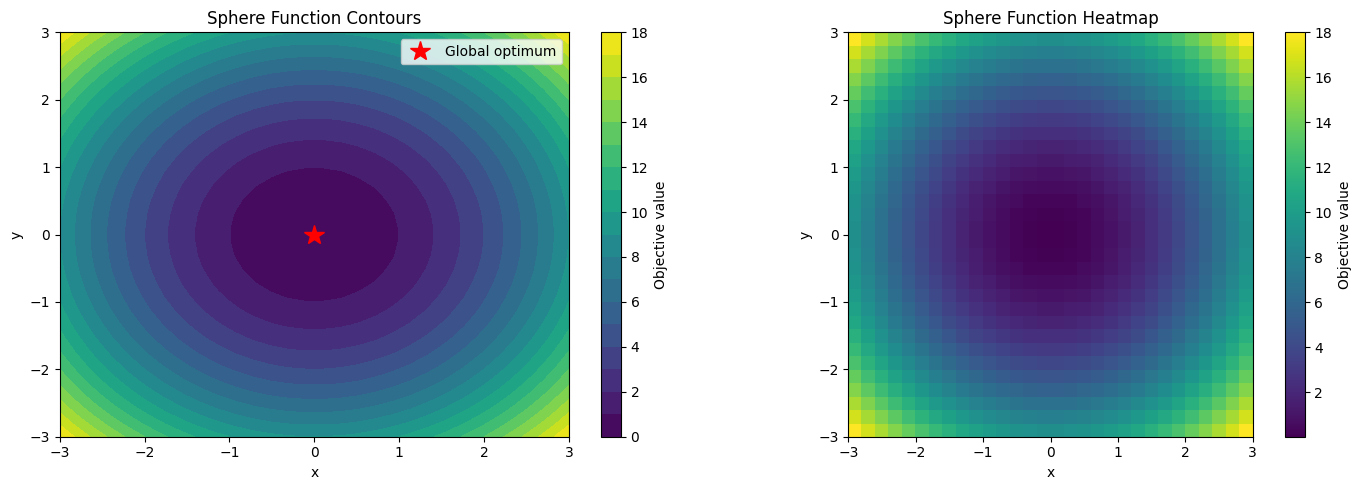


✓ Fitness landscape visualized


In [6]:
# Example 4: Visualizing fitness landscapes

# Create a grid of 2D points and evaluate with Sphere
x = jnp.linspace(-3, 3, 30)
y = jnp.linspace(-3, 3, 30)
X, Y = jnp.meshgrid(x, y)

# Sphere function
Z = X**2 + Y**2

# Create evaluator
config = SphereConfig(maximize=False)
evaluator = SphereEvaluator(config=config)

print("=== Fitness Landscape Visualization ===")
print(f"Grid size: {X.shape}")
print(f"Objective range: [{jnp.min(Z):.2f}, {jnp.max(Z):.2f}]")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contour plot
contour = axes[0].contourf(X, Y, Z, levels=20, cmap="viridis")
axes[0].plot(0, 0, "r*", markersize=15, label="Global optimum")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Sphere Function Contours")
axes[0].legend()
plt.colorbar(contour, ax=axes[0], label="Objective value")

# Surface plot (3D-like via heatmap)
im = axes[1].imshow(Z, extent=[-3, 3, -3, 3], origin="lower", cmap="viridis")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Sphere Function Heatmap")
plt.colorbar(im, ax=axes[1], label="Objective value")

plt.tight_layout()
plt.show()

print("\n✓ Fitness landscape visualized")